In [53]:
import sys
print(sys.executable)

/opt/miniconda3/envs/cfb_model/bin/python


In [55]:
from dotenv import load_dotenv
import os
import time
import cfbd
import pandas as pd
from pathlib import Path

In [56]:
load_dotenv()

API_KEY = os.environ.get("CFBD_API_KEY")

if API_KEY is None:
    raise ValueError("CFBD_API_KEY not set in environment variables")

SEASONS = list(range(2010, 2025))
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)
SLEEP = 1.0

In [58]:
# API Setup
configuration = cfbd.Configuration()
configuration.access_token = API_KEY
# configuration.api_key['Authorization'] = API_KEY
configuration.api_key_prefix['Authorization'] = "Bearer"

def get_client():
    # print(cfbd.ApiClient(configuration))
    return cfbd.ApiClient(configuration)

def check_api_quota():
    with get_client() as client:
        info_api = cfbd.InfoApi(client)
        info = info_api.get_user_info()
        print(f" API quota remaining: {info.usage.calls_remaining} calls")


## Data Collection

In [79]:
# get the drives
def fetch_drives(seasons: list[int]) -> pd.DataFrame:
    print("\n[1/4] Fetching drives...")
    all_drives = []
    with get_client() as client:
        plays_api = cfbd.DrivesApi(client)
        for season in seasons:
            print(f"  Season {season}...", end=" ")
            try:
                drives = plays_api.get_drives(
                    year=season,
                    season_type="regular"
                )
                records = []
                for d in drives:
                    row = d.to_dict()
                    # Flatten start_time clock object into plain columns
                    clock = row.get("startTime") or {}
                    if hasattr(clock, "minutes"):        # still a cfbd Clock object
                        row["start_minutes"] = clock.minutes or 0
                        row["start_seconds"] = clock.seconds or 0
                    elif isinstance(clock, dict):        # already a dict
                        row["start_minutes"] = clock.get("minutes") or 0
                        row["start_seconds"] = clock.get("seconds") or 0
                    else:
                        row["start_minutes"] = 0
                        row["start_seconds"] = 0
                    records.append(row)
                for r in records:
                    r["season"] = season
                all_drives.extend(records)
                print(f"  {len(records):,} drives")
            except cfbd.ApiException as e:
                print(f"ERROR: {e}")
            time.sleep(SLEEP)

    df = pd.DataFrame(all_drives)
    print(f"  Total: {len(df):,} drives across {len(seasons)} seasons")
    return df

In [6]:
# get the games
def fetch_games(seasons: list[int]) -> pd.DataFrame:
    print("\n[2/4] Fetching games...")
    all_games = []
    with get_client() as client:
        games_api = cfbd.GamesApi(client)
        for season in seasons:
            try:
                print(f"  Season {season} ")
                games = games_api.get_games(
                    year=season,
                    season_type="regular"
                )
                records = [g.to_dict() for g in games]
                for r in records:
                    r['season'] = season
                all_games.extend(records)
                print(f"   {len(records):,} games")
            except cfbd.ApiException as e:
                print(f"ERROR: {e}")
            time.sleep(SLEEP)

    df = pd.DataFrame(all_games)
    print(f"  Total: {len(df):,} games")
    return df

In [ ]:
def fetch_team_ratings(seasons: list[int]) -> pd.DataFrame:
    print("\n[3/4] Fetching team ratings...")
    sp_records = []
    elo_records = []

    with get_client() as client:
        ratings_api = cfbd.RatingsApi(client)

        for season in seasons:
            print(f"  Season {season} SP+...", end=" ")
            try:
                sp = ratings_api.get_sp(year=season)
                records = [s.to_dict() for s in sp]
                for r in records:
                    r['season'] = season
                sp_records.extend(records)
                print(f"  {len(sp_records):,} teams")
            except cfbd.ApiException as e:
                print(f"SP ERROR: {e}")
            time.sleep(SLEEP)

            print("Elo..." , end=" ")
            try:
                elo = ratings_api.get_elo(year=season)
                records = [e.to_dict() for e in elo]
                for r in records:
                    r['season'] = season
                elo_records.extend(records)
                print(f"  {len(elo_records):,} teams")
            except cfbd.ApiException as e:
                print(f"ELO ERROR: {e}")
            time.sleep(SLEEP)
    
    sp_df = pd.DataFrame(sp_records)
    elo_df = pd.DataFrame(elo_records)

    if not elo_df.empty and not sp_df.empty:
        ratings_df = sp_df.merge(elo_df[["team", "season", "elo"]], on=['team', "season"], how="left")
    else:
        ratings_df = sp_df if not sp_df.empty else elo_df

    print(f"  Total: {len(ratings_df):,} team-season stats")
    return ratings_df
    

In [8]:
# get the team stats
def fetch_team_stats(seasons: list[int]) -> pd.DataFrame:
    print("\n[4/4] Fetching team stats...")
    all_stats = []
    with get_client() as client:
        stats_api = cfbd.StatsApi(client)
        for season in seasons:
            try:
                print(f"  Season {season} ")
                stats = stats_api.get_team_stats(
                    year=season,
                )
                records = [s.to_dict() for s in stats]
                for r in records:
                    r['season'] = season
                all_stats.extend(records)
                print(f"  {len(records):,} team-stats records")
            except cfbd.ApiException as e:
                print(f"ERROR: {e}")
            time.sleep(SLEEP)

    df = pd.DataFrame(all_stats)
    print(f"  Total: {len(df):,} team-stats")
    return df

In [ ]:
import requests

def fetch_ppa(seasons: list[int], api_key: str) -> pd.DataFrame:
    print("\n[5/5] Fetching PPA ratings...")
    records = []
    headers = {"Authorization": f"Bearer {api_key}"}

    for season in seasons:
        print(f"  Season {season}...", end=" ")
        try:
            response = requests.get(
                "https://api.collegefootballdata.com/ppa/teams",
                headers=headers,
                params={"year": season}
            )
            response.raise_for_status()
            data = response.json()

            for entry in data:
                row = {
                    "team":   entry.get("team"),
                    "season": season,
                }
                # flatten out the metrics
                off = entry.get("offense", {}) or {}
                row["ppa_off_overall"]    = off.get("overall")
                row["ppa_off_passing"]    = off.get("passing")
                row["ppa_off_rushing"]    = off.get("rushing")
                row["ppa_off_third_down"] = off.get("thirdDown")

                def_ = entry.get("defense", {}) or {}
                row["ppa_def_overall"]    = def_.get("overall")
                row["ppa_def_passing"]    = def_.get("passing")
                row["ppa_def_rushing"]    = def_.get("rushing")
                row["ppa_def_third_down"] = def_.get("thirdDown")

                records.append(row)

            print(f"{len(data)} teams")

        except requests.HTTPError as e:
            print(f"HTTP ERROR: {e}")
        except Exception as e:
            print(f"ERROR: {e}")

        time.sleep(SLEEP)

    df = pd.DataFrame(records)
    print(f"  Total: {len(df):,} team-season PPA records")
    return df


In [135]:
#### Load to csv's so we don't have to do this too many times
df = fetch_drives(seasons=SEASONS)
df.to_csv("data/drives.csv")

df_games = fetch_games(seasons=SEASONS)
df_games.to_csv('data/games.csv')

df_ratings = fetch_team_ratings(seasons=SEASONS)
df_ratings.to_csv('data/team_ratings.csv')

df_stats = fetch_team_stats(seasons=SEASONS)
df_stats.to_csv('data/team_stats.csv')

ppa_df = fetch_ppa(SEASONS, API_KEY)
ppa_df.to_csv("data/ppa.csv", index=False)


[1/4] Fetching drives...
  Season 2010...   19,254 drives
  Season 2011...   19,841 drives
  Season 2012...   20,700 drives
  Season 2013...   21,796 drives
  Season 2014...   21,436 drives
  Season 2015...   21,758 drives
  Season 2016...   21,436 drives
  Season 2017...   21,439 drives
  Season 2018...   21,734 drives
  Season 2019...   21,412 drives
  Season 2020...   13,506 drives
  Season 2021...   20,714 drives
  Season 2022...   34,492 drives
  Season 2023...   33,950 drives
  Season 2024...   36,619 drives
  Total: 350,087 drives across 15 seasons

[2/4] Fetching games...
  Season 2010 
   1,427 games
  Season 2011 
   1,463 games
  Season 2012 
   1,344 games
  Season 2013 
   1,496 games
  Season 2014 
   1,542 games
  Season 2015 
   1,491 games
  Season 2016 
   1,502 games
  Season 2017 
   1,505 games
  Season 2018 
   1,511 games
  Season 2019 
   1,577 games
  Season 2020 
   563 games
  Season 2021 
   2,408 games
  Season 2022 
   3,657 games
  Season 2023 
   3,595 

## Feature Engineering

In [3]:
pd.set_option('display.max_columns', None)
# pull in data
drives_df = pd.read_csv("data/drives.csv")
games_df = pd.read_csv("data/games.csv")
team_stats_df = pd.read_csv("data/team_stats.csv")
team_ratings_df = pd.read_csv("data/team_ratings.csv")
team_ppa_df = pd.read_csv("data/ppa.csv")

# # look at data
# print(drives_df.head(10), '\n')
# print(games_df.head(10), '\n')
# print(team_stats_df.head(10), '\n')
# print(team_ratings_df.head(10), '\n')


/var/folders/lp/3q2mttvj0vb2sl6053_fvc8m0000gn/T/ipykernel_7929/3476421246.py:4: DtypeWarning: Columns (0: highlights) have mixed types. Specify dtype option on import or set low_memory=False.
  games_df = pd.read_csv("data/games.csv")


In [4]:
# clean up drive results
# print(drives_df['driveResult'].unique())
drive_map = {"TD": "TD",
             'END OF HALF TD':      "TD",
             'PUNT RETURN TD':      "TD",
             'PUNT TD':             "TD",
             'RUSHING TD':          'TD',
             "FG":                  "FG",
             'FG GOOD':             "FG",
             "MISSED FG":           "MISSED_FG",
             'FG MISSED':           "MISSED_FG",

             "PUNT":                "PUNT",
             "DOWNS":               "DOWNS",

             "FUMBLE":              "TURNOVER",
             "INT":                 "TURNOVER",
             'BLOCKED PUNT':        "TURNOVER",
             "INT TD":              "TURNOVER_TD", 
             'FUMBLE TD':           "TURNOVER_TD", 
             'FUMBLE RETURN TD':    "TURNOVER_TD",
             'MISSED FG TD':        "TURNOVER_TD",
             'DOWNS TD' :           "TURNOVER_TD",

             "END OF HALF":         "END_HALF",
             'END OF GAME':         "END_GAME", 
             'END OF 4TH QUARTER':  "END_HALF" ,

             'SF':                  "SAFETY"
             }
drives_df['drive_result'] = (drives_df['driveResult'].map(drive_map).fillna("OTHER"))
drives_df['drive_result'].unique()

<StringArray>
[       'PUNT',          'TD',       'OTHER',    'END_HALF', 'TURNOVER_TD',
          'FG',    'TURNOVER',    'END_GAME',   'MISSED_FG',      'SAFETY',
       'DOWNS']
Length: 11, dtype: str

In [6]:
# bring in game features
# print(games_df.columns)
game_features = ["id", "homeTeam", "awayTeam", "neutralSite", "homePoints", "awayPoints"]
games_slim = games_df[game_features].rename(columns={'id': 'gameId'})
df = drives_df.merge(games_slim, on=['gameId'], how="left")

df["quarter_seconds_remaining"] = (df["start_minutes"] * 60) + df['start_seconds']

# Minutes remaining in game (approx): each quarter = 15 min = 900 sec
df["game_minutes_remaining"] = (
    (4 - df["startPeriod"].clip(1, 4)) * 900
    + df["quarter_seconds_remaining"]
) / 60

# set up neutralsite
df['neutralSite'] = df['neutralSite'].fillna(False).astype(int)

# set up the drive starting score differential
df['startScoreDiff'] = df['startOffenseScore'] - df['startDefenseScore']
# display(df.iloc[:, 1:])

In [7]:
#### pull the offensive and defensive SP/ELO
# display(df_ratings)
sp_cols = ["team", "season"]
off_ratings_cols = {c: f"off_{c}" for c in team_ratings_df.columns if c not in sp_cols}
off_ratings = team_ratings_df.rename(columns={**off_ratings_cols, "team": "offense"})
def_ratings = team_ratings_df.rename(columns={
    **{c: f"def_{c}" for c in team_ratings_df if c not in sp_cols}, "team": "defense"
})

df = df.merge(off_ratings, on=["offense", "season"], how="left")
df = df.merge(def_ratings, on=['defense', 'season'], how='left')

# display(df.iloc[:, 1:])

In [8]:
#### pull the offensive and defensive ppa values
off_ppa_cols = ["team", "season", 'ppa_off_overall', 'ppa_off_passing', 'ppa_off_rushing', 'ppa_off_third_down']
def_ppa_cols = ["team", "season", 'ppa_def_overall', 'ppa_def_passing', 'ppa_def_rushing', 'ppa_def_third_down']
off_ratings = team_ppa_df[off_ppa_cols]
def_ratings = team_ppa_df[def_ppa_cols]

df = df.merge(off_ratings, left_on=["offense", "season"], right_on=['team', 'season'], how="left")
df = df.merge(def_ratings, left_on=["defense", "season"], right_on=['team', 'season'], how="left")

# display(df.iloc[:, 1:])

In [9]:
feature_cols = [
    "gameId", "driveNumber", "season",
    "offense", "defense",

    # Drive context
    "startYardline",
    "startPeriod",
    "game_minutes_remaining",
    "startScoreDiff",
    "isHomeOffense",
    "neutralSite",

    # Team PPA values
    "ppa_off_overall",
    "ppa_off_passing",
    "ppa_off_rushing",
    "ppa_off_third_down",
    "ppa_def_overall",
    "ppa_def_passing",
    "ppa_def_rushing",
    "ppa_def_third_down",

    # Team strength
    "off_rating",
    "def_rating",
    "off_elo",
    "def_elo",

    # Drive outcome metadata
    "yards",
    "plays",

    # Target
    "drive_result",
]

# Only keep columns that actually exist in the merged df
final_cols = [c for c in feature_cols if c in df.columns]
modeling_df = df[final_cols].copy()
modeling_df = modeling_df[~modeling_df['drive_result'].isin(['OTHER','END_GAME', 'END_HALF'])]

print(f"  Modeling dataset: {len(modeling_df):,} rows x {len(modeling_df.columns)} columns")
print(f"  Drive result distribution:")
print(modeling_df["drive_result"].value_counts(normalize=True)
        .mul(100).round(1).to_string())

modeling_df.to_csv("data/modeling_data.csv")


  Modeling dataset: 310,729 rows x 26 columns
  Drive result distribution:
drive_result
PUNT           41.7
TD             26.7
TURNOVER       11.9
FG              9.5
DOWNS           5.4
MISSED_FG       3.4
TURNOVER_TD     1.2
SAFETY          0.2


## Model Training

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path

# pipeline & metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (
    classification_report, log_loss, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# models
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


In [12]:
# set up configs
DATA_PATH = Path("data/modeling_data.csv")
MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR = Path("reports"); REPORT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
TEST_SIZE = .2
VAL_SEASON = 2024

OUTCOME_CATEGORIES = ['PUNT', 'TD', 'TURNOVER', 'FG', 'DOWNS', 'MISSED_FG', 'END_HALF', 'END_GAME', 'TURNOVER_TD', 'OTHER', 'END_FOUR', 'SAFETY']
FEATURE_COLS = [
    # Drive context
    "startYardline",
    "startPeriod",
    'game_minutes_remaining',
    "startScoreDiff",
    "isHomeOffense",
    "neutralSite",

    # Team PPA values
    "ppa_off_overall",
    "ppa_off_passing",
    "ppa_off_rushing",
    "ppa_off_third_down",
    "ppa_def_overall",
    "ppa_def_passing",
    "ppa_def_rushing",
    "ppa_def_third_down",

    # Team strength
    "off_rating",
    "def_rating",
    "off_elo",
    "def_elo"
]

TARGET = 'drive_result'

In [13]:
############ Data Loading ###############
df = pd.read_csv(DATA_PATH)
print(f"Orig DataFrame: {len(df):,} rows x {df.shape[1]} columns")

missing = df[FEATURE_COLS + [TARGET]].isnull().sum()
missing = missing[missing > 0]
print("\n Missing values: ")
print(missing.to_string())

# looks like a bunch of d2 schools which is fine considering 
# as they won't make the playoffs...so I'm just dropping those rows for now
display(df[df['off_rating'].isnull()]['offense'].unique())

# drop those rows
df = df.dropna().copy()

print(f"New DataFrame: {len(df):,} rows x {df.shape[1]} columns")
missing = df[FEATURE_COLS + [TARGET]].isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print("\n Missing values: ")
    print(missing.to_string())

Orig DataFrame: 310,729 rows x 27 columns

 Missing values: 
ppa_off_overall       57534
ppa_off_passing       57534
ppa_off_rushing       57534
ppa_off_third_down    57534
ppa_def_overall       56702
ppa_def_passing       56702
ppa_def_rushing       56702
ppa_def_third_down    56702
off_rating            57811
def_rating            56986
off_elo               57811
def_elo               56986


<StringArray>
[               'North Dakota',                      'Towson',
                'Presbyterian',               'Norfolk State',
    'Southeast Missouri State',                'Rhode Island',
                     'Hampton',                 'Florida A&M',
          'Eastern Washington',                'SE Louisiana',
 ...
             'Hanover College',                     'Catawba',
            'Point University',        'Ave Maria University',
                 'Sioux Falls',           'Black Hills State',
          'Central State (OH)',          'Central Washington',
                   'Roosevelt', 'Georgetown College Kentucky']
Length: 205, dtype: str

New DataFrame: 235,786 rows x 27 columns


In [14]:
############### Preprocessing ###############
X = df[FEATURE_COLS].copy()

# clean field position
if "startYardline" in X.columns:
    X['startYardline'] = X["startYardline"].clip(1, 99)

# encode target labels
le = LabelEncoder()
y = le.fit_transform(df[TARGET])


print(f"Features used ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target Classes: {list(le.classes_)}")

Features used (18): ['startYardline', 'startPeriod', 'game_minutes_remaining', 'startScoreDiff', 'isHomeOffense', 'neutralSite', 'ppa_off_overall', 'ppa_off_passing', 'ppa_off_rushing', 'ppa_off_third_down', 'ppa_def_overall', 'ppa_def_passing', 'ppa_def_rushing', 'ppa_def_third_down', 'off_rating', 'def_rating', 'off_elo', 'def_elo']
Target Classes: ['DOWNS', 'FG', 'MISSED_FG', 'PUNT', 'SAFETY', 'TD', 'TURNOVER', 'TURNOVER_TD']


In [33]:
# Set up train/test split based on year
test_mask = df['season'] == VAL_SEASON
train_mask = df['season'] < VAL_SEASON

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
print(f"Training Data has {len(X_train)} rows")
print(f"Testing Data has {len(X_test)} rows")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
)

Training Data has 219206 rows
Testing Data has 16580 rows


Nearest Neighbors Model

In [34]:
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_dist = {
    "knn__n_neighbors": [5, 15, 30],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],  # 1 = Manhattan, 2 = Euclidean
    "knn__leaf_size": [20, 40, 60]
}

knn_random = RandomizedSearchCV(
    knn_pipe,
    param_distributions=param_dist,
    n_iter=15,
    scoring="neg_log_loss",   # 🔑 key for your project
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

knn_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END knn__leaf_size=60, knn__n_neighbors=5, knn__p=2, knn__weights=uniform; total time=  23.7s
[CV] END knn__leaf_size=60, knn__n_neighbors=5, knn__p=2, knn__weights=uniform; total time=  23.7s
[CV] END knn__leaf_size=60, knn__n_neighbors=30, knn__p=2, knn__weights=distance; total time=  23.8s
[CV] END knn__leaf_size=60, knn__n_neighbors=5, knn__p=2, knn__weights=uniform; total time=  24.1s
[CV] END knn__leaf_size=60, knn__n_neighbors=15, knn__p=2, knn__weights=uniform; total time=  24.0s
[CV] END knn__leaf_size=60, knn__n_neighbors=30, knn__p=2, knn__weights=distance; total time=  24.3s
[CV] END knn__leaf_size=60, knn__n_neighbors=30, knn__p=2, knn__weights=distance; total time=  24.6s
[CV] END knn__leaf_size=60, knn__n_neighbors=15, knn__p=2, knn__weights=uniform; total time=  25.2s
[CV] END knn__leaf_size=60, knn__n_neighbors=15, knn__p=2, knn__weights=uniform; total time=  25.4s
[CV] END knn__leaf_size=60, knn__n_neig

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'knn__leaf_size': [20, 40, ...], 'knn__n_neighbors': [5, 15, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [35]:
best_knn = knn_random.best_estimator_

print("Best Params:", knn_random.best_params_)
print("Best CV Log-Loss:", -knn_random.best_score_)

knn_probs = best_knn.predict_proba(X_val)
knn_logloss = log_loss(y_val, knn_probs)

print(f"KNN Test Log-Loss: {knn_logloss:.4f}")

Best Params: {'knn__weights': 'uniform', 'knn__p': 1, 'knn__n_neighbors': 30, 'knn__leaf_size': 20}
Best CV Log-Loss: 2.6565327840967154
KNN Test Log-Loss: 2.5675


SVM Model

In [32]:
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

param_dist = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["rbf", "linear"],
    "svm__gamma": ["scale", "auto"]
}

svm_random = RandomizedSearchCV(
    svm_pipe,
    param_distributions=param_dist,
    n_iter=5,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

svm_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


KeyboardInterrupt: 

In [ ]:
best_svm = svm_random.best_estimator_

print("Best Params:", svm_random.best_params_)
print("Best CV Log-Loss:", -svm_random.best_score_)

svm_probs = best_svm.predict_proba(X_val)
svm_logloss = log_loss(y_val, svm_probs)

print(f"SVM Test Log-Loss: {svm_logloss:.4f}")

Naive Bayes Model

In [36]:
nb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

param_dist = {
    "nb__var_smoothing": np.logspace(-11, -7, 5)
}

from sklearn.model_selection import RandomizedSearchCV

nb_random = RandomizedSearchCV(
    nb_pipe,
    param_distributions=param_dist,
    n_iter=5,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

nb_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ............................nb__var_smoothing=1e-11; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-10; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-11; total time=   0.4s
[CV] END ............................nb__var_smoothing=1e-11; total time=   0.4s
[CV] END ............................nb__var_smoothing=1e-10; total time=   0.4s
[CV] END ............................nb__var_smoothing=1e-10; total time=   0.4s
[CV] END ............................nb__var_smoothing=1e-09; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-09; total time=   0.4s
[CV] END ............................nb__var_smoothing=1e-09; total time=   0.4s
[CV] END ............................nb__var_smoothing=1e-08; total time=   0.3s
[CV] END ............................nb__var_smoothing=1e-08; total time=   0.2s
[CV] END ............................nb__var_smoo

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...aussianNB())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'nb__var_smoothing': array([1.e-11...e-08, 1.e-07])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold 

In [37]:
best_nb = nb_random.best_estimator_

print("Best Params:", nb_random.best_params_)
print("Best CV Log-Loss:", -nb_random.best_score_)

nb_probs = best_nb.predict_proba(X_val)
nb_logloss = log_loss(y_val, nb_probs)

print(f"Naive Bayes Test Log-Loss: {nb_logloss:.4f}")

Best Params: {'nb__var_smoothing': np.float64(1e-07)}
Best CV Log-Loss: 1.7917257859417035
Naive Bayes Test Log-Loss: 1.7749


Logistic Regression Model

In [39]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

param_dist = {
    "logreg__C": np.logspace(-3, 2, 6),   # regularization strength
    "logreg__penalty": ["l2"],            # keep simple
    "logreg__solver": ["lbfgs", "saga"]
}

logreg_random = RandomizedSearchCV(
    logreg_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

logreg_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

[CV] END logreg__C=0.001, logreg__penalty=l2, logreg__solver=lbfgs; total time=   0.9s
[CV] END logreg__C=0.001, logreg__penalty=l2, logreg__solver=lbfgs; total time=   1.0s
[CV] END logreg__C=0.001, logreg__penalty=l2, logreg__solver=lbfgs; total time=   1.1s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be remov

[CV] END logreg__C=100.0, logreg__penalty=l2, logreg__solver=lbfgs; total time=   2.0s
[CV] END logreg__C=100.0, logreg__penalty=l2, logreg__solver=lbfgs; total time=   2.1s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=10.0, logreg__penalty=l2, logreg__solver=lbfgs; total time=   2.1s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=100.0, logreg__penalty=l2, logreg__solver=lbfgs; total time=   2.6s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=10.0, logreg__penalty=l2, logreg__solver=lbfgs; total time=   1.7s
[CV] END logreg__C=0.01, logreg__penalty=l2, logreg__solver=lbfgs; total time=   1.0s
[CV] END logreg__C=10.0, logreg__penalty=l2, logreg__solver=lbfgs; total time=   2.3s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=0.01, logreg__penalty=l2, logreg__solver=lbfgs; total time=   1.0s
[CV] END logreg__C=0.01, logreg__penalty=l2, logreg__solver=lbfgs; total time=   1.0s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=0.001, logreg__penalty=l2, logreg__solver=saga; total time=   2.1s
[CV] END logreg__C=0.001, logreg__penalty=l2, logreg__solver=saga; total time=   2.2s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=0.001, logreg__penalty=l2, logreg__solver=saga; total time=   2.1s
[CV] END logreg__C=0.1, logreg__penalty=l2, logreg__solver=saga; total time=   4.6s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=0.1, logreg__penalty=l2, logreg__solver=saga; total time=   4.4s
[CV] END logreg__C=0.1, logreg__penalty=l2, logreg__solver=saga; total time=   4.7s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=0.1, logreg__penalty=l2, logreg__solver=lbfgs; total time=   1.5s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=0.1, logreg__penalty=l2, logreg__solver=lbfgs; total time=   1.7s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END logreg__C=0.1, logreg__penalty=l2, logreg__solver=lbfgs; total time=   1.5s
[CV] END logreg__C=10.0, logreg__penalty=l2, logreg__solver=saga; total time=  12.7s
[CV] END logreg__C=10.0, logreg__penalty=l2, logreg__solver=saga; total time=  13.4s
[CV] END logreg__C=10.0, logreg__penalty=l2, logreg__solver=saga; total time=  13.6s
[CV] END logreg__C=100.0, logreg__penalty=l2, logreg__solver=saga; total time=  11.4s
[CV] END logreg__C=1.0, logreg__penalty=l2, logreg__solver=saga; total time=   9.1s
[CV] END logreg__C=1.0, logreg__penalty=l2, logreg__solver=saga; total time=   8.8s
[CV] END logreg__C=1.0, logreg__penalty=l2, logreg__solver=saga; total time=   9.0s
[CV] END logreg__C=100.0, logreg__penalty=l2, logreg__solver=saga; total time=  11.4s
[CV] END logreg__C=100.0, logreg__penalty=l2, logreg__solver=saga; total time=  11.6s


/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'logreg__C': array([1.e-03...e+01, 1.e+02]), 'logreg__penalty': ['l2'], 'logreg__solver': ['lbfgs', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged

In [40]:
best_logreg = logreg_random.best_estimator_

print("Best Params:", logreg_random.best_params_)
print("Best CV Log-Loss:", -logreg_random.best_score_)

logreg_probs = best_logreg.predict_proba(X_val)
logreg_logloss = log_loss(y_val, logreg_probs)

print(f"Logistic Regression Test Log-Loss: {logreg_logloss:.4f}")

Best Params: {'logreg__solver': 'saga', 'logreg__penalty': 'l2', 'logreg__C': np.float64(1.0)}
Best CV Log-Loss: 1.4747104452694046
Logistic Regression Test Log-Loss: 1.4722


Random Forest Model

In [41]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=  26.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=  26.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=  26.3s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  27.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  27.5s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  27.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  28.4s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_

/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   6.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   6.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   5.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  21.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  21.4s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  19.9s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  20.7s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  21.2s
[CV] END max_depth=10, max_feature

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [42]:
best_rf = rf_random.best_estimator_

print("Best Params:", rf_random.best_params_)
print("Best CV Log-Loss:", -rf_random.best_score_)

rf_probs = best_rf.predict_proba(X_val)
rf_logloss = log_loss(y_val, rf_probs)

print(f"Random Forest Test Log-Loss: {rf_logloss:.4f}")

Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Best CV Log-Loss: 1.4410971663564895
Random Forest Test Log-Loss: 1.4359


XGBoost Model

In [43]:
################ Modeling ###################

# need to set up gridsearch cv and test out additional models

# neat little trick here. Going to use DummyClassifier to get the baseline score neccessary in models
# https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
dummy_probs = dummy.predict_proba(X_test)
baseline_11 = log_loss(y_test, dummy_probs)
print(f"Baseline log-loss (stratified dummy): {baseline_11:.4f}")

Baseline log-loss (stratified dummy): 26.6523


In [45]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 5, 10],
    "gamma": [0, 0.1, 0.3]
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_tr, y_tr)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END colsample_bytree=0.85, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=10, n_estimators=200, subsample=1.0; total time=   9.4s
[CV] END colsample_bytree=0.85, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=10, n_estimators=200, subsample=1.0; total time=   9.6s
[CV] END colsample_bytree=0.85, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=10, n_estimators=200, subsample=1.0; total time=   9.7s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=200, subsample=1.0; total time=   9.7s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=200, subsample=0.85; total time=  18.5s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=200, subsample=1.0; total time=   9.2s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rat

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=8, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.85, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used 

In [46]:
best_xgb = xgb_random.best_estimator_

print("Best Params:", xgb_random.best_params_)
print("Best CV Log-Loss:", -xgb_random.best_score_)

xgb_probs = best_xgb.predict_proba(X_val)
xgb_logloss = log_loss(y_val, xgb_probs)

print(f"XGBoost Test Log-Loss: {xgb_logloss:.4f}")

Best Params: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.85}
Best CV Log-Loss: 1.3985274310908595
XGBoost Test Log-Loss: 1.3898


In [49]:
calibrated = CalibratedClassifierCV(
    best_xgb, method="isotonic", cv=5
)
calibrated.fit(X_train, y_train)

# Raw test results
raw_probs = best_xgb.predict_proba(X_test)
raw_11 = log_loss(y_test, raw_probs)
raw_preds = best_xgb.predict(X_test)

cal_probs = calibrated.predict_proba(X_test)
cal_11 = log_loss(y_test, cal_probs)
cal_preds = calibrated.predict(X_test)

print("Log-Loss Results")
print(f"  Baseline (dummy):     {baseline_11:.4f}")
print(f"  XGBoost (raw):        {raw_11:.4f}")
print(f"  XGBoost (calibrated): {cal_11:.4f}")

Log-Loss Results
  Baseline (dummy):     26.6523
  XGBoost (raw):        1.4606
  XGBoost (calibrated): 1.4796


In [50]:
# take a look at your classification report
# decent accuracy. Biggest concern is really the FG percentage
report = classification_report(y_test, raw_preds, target_names=le.classes_)
print(f"\n  Classification Report:\n{report}")


  Classification Report:
              precision    recall  f1-score   support

       DOWNS       0.36      0.06      0.11      1263
          FG       0.37      0.01      0.02      1788
   MISSED_FG       0.17      0.00      0.00       556
        PUNT       0.46      0.82      0.59      6190
      SAFETY       0.00      0.00      0.00        46
          TD       0.45      0.48      0.47      4770
    TURNOVER       0.27      0.04      0.06      1798
 TURNOVER_TD       0.00      0.00      0.00       169

    accuracy                           0.45     16580
   macro avg       0.26      0.18      0.16     16580
weighted avg       0.41      0.45      0.37     16580



/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/cfb_model/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

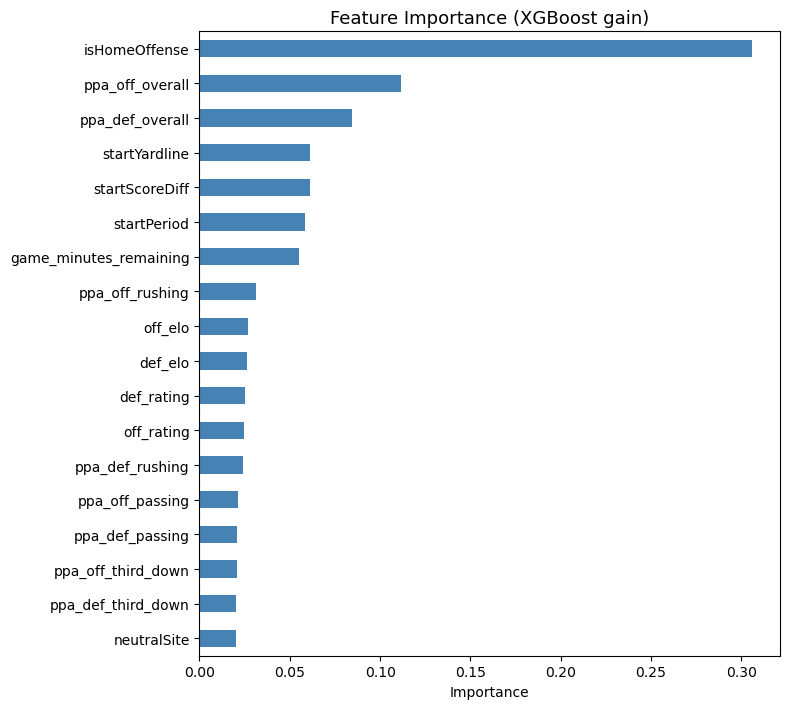

In [51]:
# plot the feature importance
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(FEATURE_COLS) * 0.4)))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance (XGBoost gain)", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()

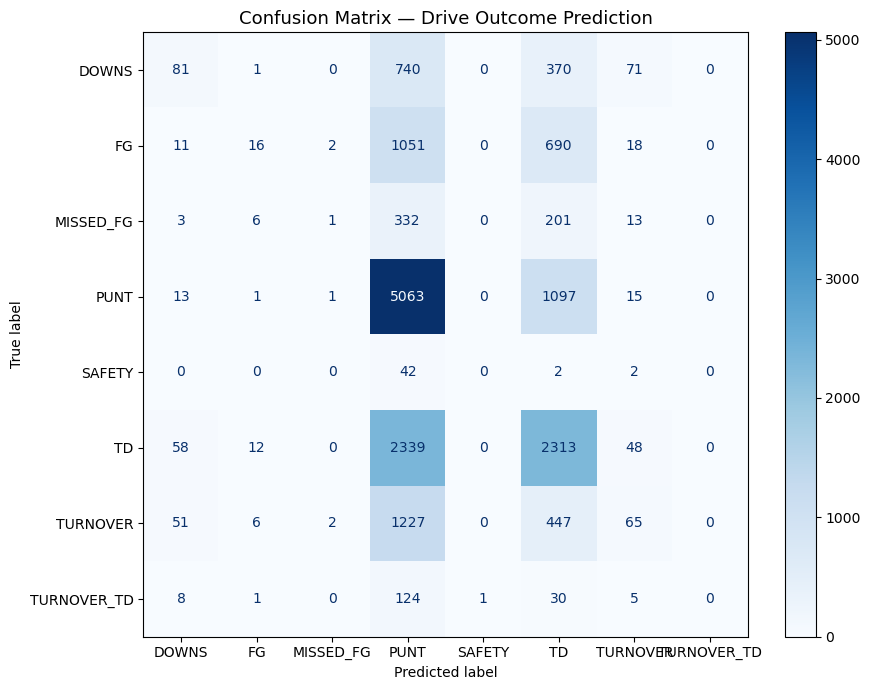

In [52]:
# plot the confusion matrix
cm = confusion_matrix(y_test, raw_preds)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Drive Outcome Prediction", fontsize=13)
plt.tight_layout()

In [21]:
for i, cls in enumerate(le.classes_):
    y_binary = (y_test == i).astype(int)
    fraction_pos, mean_pred = calibration_curve(
        y_binary, cal_probs[:, i], n_bins=10
    )
    mace = np.mean(np.abs(fraction_pos - mean_pred))
    print(f"{cls:<12}: MACE = {mace:.4f}")

DOWNS       : MACE = 0.0724
FG          : MACE = 0.1013
MISSED_FG   : MACE = 0.0200
PUNT        : MACE = 0.1271
SAFETY      : MACE = 0.1473
TD          : MACE = 0.1510
TURNOVER    : MACE = 0.1263
TURNOVER_TD : MACE = 0.0017


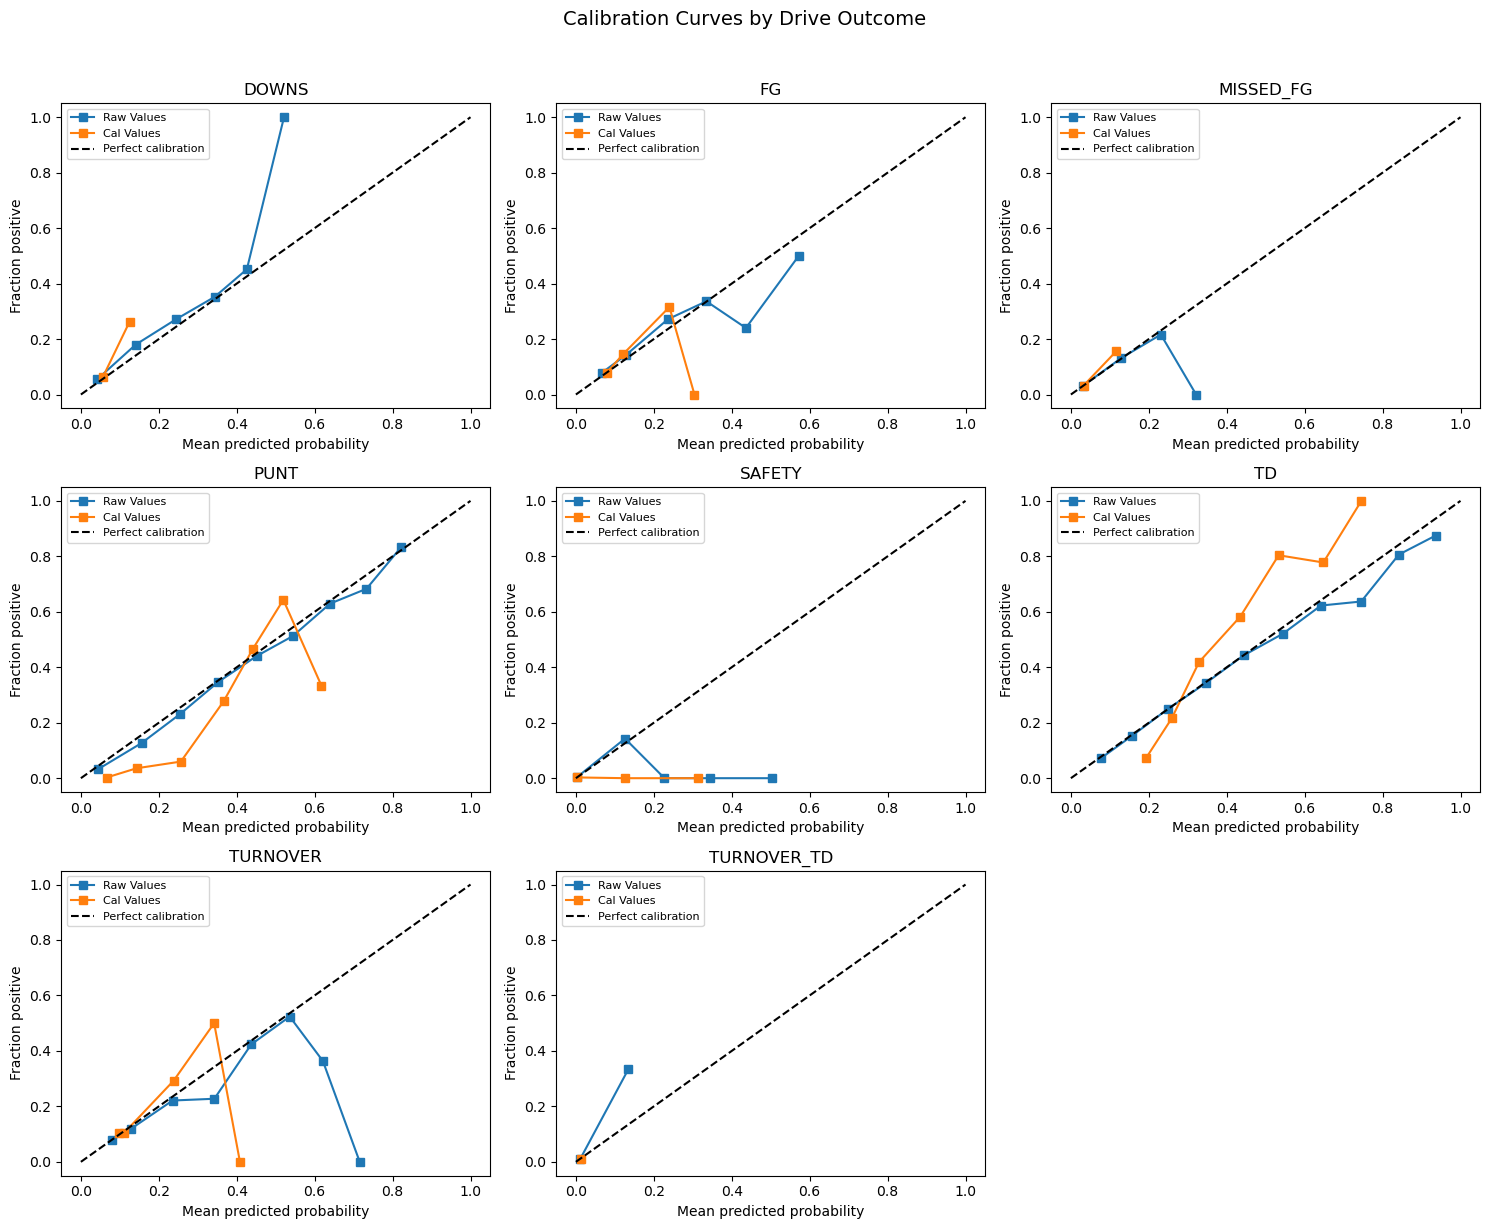

In [22]:
probs = calibrated.predict_proba(X_test)
n_classes = len(le.classes_)
cols = min(3, n_classes)
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten() if n_classes > 1 else [axes]

for i, cls in enumerate(le.classes_):
    y_binary = (y_test == i).astype(int)
    fraction_pos, mean_pred = calibration_curve(y_binary, raw_probs[:, i], n_bins=10)
    f_pos, m_pred = calibration_curve(y_binary, cal_probs[:, i], n_bins=10)
    axes[i].plot(mean_pred, fraction_pos, "s-", label="Raw Values")
    axes[i].plot(m_pred, f_pos, "s-", label="Cal Values")
    axes[i].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    axes[i].set_title(f"{cls}")
    axes[i].set_xlabel("Mean predicted probability")
    axes[i].set_ylabel("Fraction positive")
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Calibration Curves by Drive Outcome", fontsize=14, y=1.02)
plt.tight_layout()
